
==================== BASELINE SVM ANALYSIS ====================
Baseline SVC Accuracy (Default RBF): 75.32%

==================== SVM TUNING TRIALS ====================
Trial 1 (Linear Kernel) completed.
Trial 2 (RBF Kernel - C & Gamma) completed.
Trial 3 (Poly Kernel - Degree) completed.

SVM HYPERPARAMETER TUNING SUMMARY:
                           Trial                              Best Params  Test Accuracy
         Trial 1 (Linear Kernel)           {'C': 0.1, 'kernel': 'linear'}       0.720779
Trial 2 (RBF Kernel - C & Gamma) {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}       0.733766
  Trial 3 (Poly Kernel - Degree) {'C': 10, 'degree': 3, 'kernel': 'poly'}       0.688312

==================== FINAL MODEL EVALUATION ====================
Best Model Parameters: Kernel=rbf, C=1, Gamma=0.01


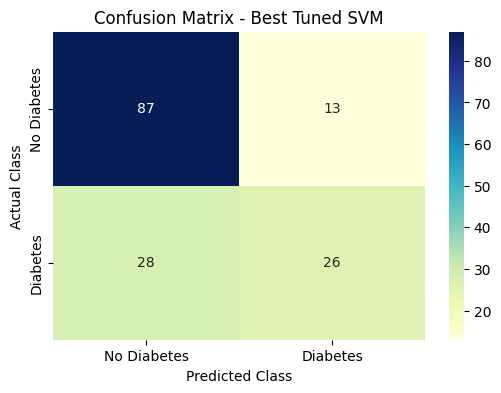


Final Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.76      0.87      0.81       100
    Diabetes       0.67      0.48      0.56        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.68       154
weighted avg       0.73      0.73      0.72       154


Generating 2D Decision Boundary Plot...


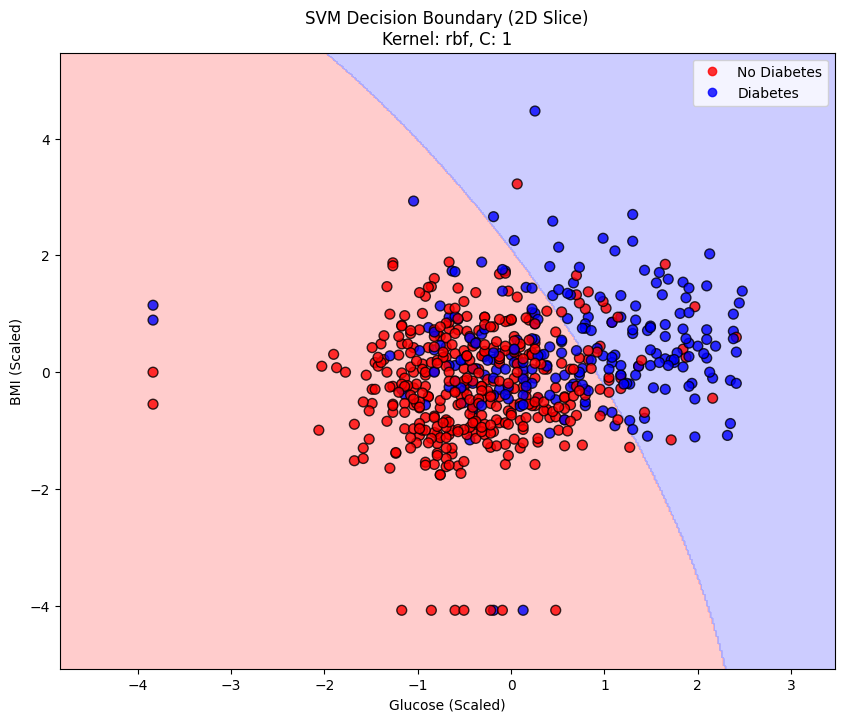

In [ ]:
# ----------------- 0. IMPORT LIBRARIES -----------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ----------------- 1. LOAD DATA -----------------
data = pd.read_csv('diabetes.csv')  # Make sure your file name matches
X = data.drop('Outcome', axis=1)
y = data['Outcome']
feature_names = X.columns
target_names = ['No Diabetes', 'Diabetes']

# ----------------- 2. TRAIN/TEST SPLIT & SCALING -----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------- 3. BASELINE SVM MODEL -----------------
print("\n" + "="*20 + " BASELINE SVM ANALYSIS " + "="*20)
baseline_svm = SVC(random_state=42)
baseline_svm.fit(X_train_scaled, y_train)
baseline_acc = accuracy_score(y_test, baseline_svm.predict(X_test_scaled))
print(f"Baseline SVC Accuracy (Default RBF): {baseline_acc * 100:.2f}%")

# ----------------- 4. HYPERPARAMETER TUNING TRIALS -----------------
print("\n" + "="*20 + " SVM TUNING TRIALS " + "="*20)
svm_trials = {
    "Trial 1 (Linear Kernel)": {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1, 10]
    },
    "Trial 2 (RBF Kernel - C & Gamma)": {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 0.01, 0.1, 1]
    },
    "Trial 3 (Poly Kernel - Degree)": {
        'kernel': ['poly'],
        'degree': [2, 3, 4],
        'C': [1, 10]
    }
}

trial_results = []
best_overall_model = None
best_overall_acc = 0

for name, params in svm_trials.items():
    grid = GridSearchCV(SVC(random_state=42), params, cv=5, scoring='accuracy')
    grid.fit(X_train_scaled, y_train)
    best_trial_model = grid.best_estimator_
    acc = accuracy_score(y_test, best_trial_model.predict(X_test_scaled))
    if acc > best_overall_acc:
        best_overall_acc = acc
        best_overall_model = best_trial_model
    trial_results.append({
        "Trial": name,
        "Best Params": grid.best_params_,
        "Test Accuracy": acc
    })
    print(f"{name} completed.")

results_df = pd.DataFrame(trial_results)
print("\nSVM HYPERPARAMETER TUNING SUMMARY:")
pd.set_option('display.max_colwidth', None)
print(results_df.to_string(index=False))

# ----------------- 5. FINAL BEST MODEL EVALUATION -----------------
print("\n" + "="*20 + " FINAL MODEL EVALUATION " + "="*20)
best_params = best_overall_model.get_params()
final_kernel = best_params['kernel']
final_c = best_params['C']
final_gamma = best_params.get('gamma', 'N/A')
print(f"Best Model Parameters: Kernel={final_kernel}, C={final_c}, Gamma={final_gamma}")

y_pred_final = best_overall_model.predict(X_test_scaled)

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Best Tuned SVM")
plt.show()

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=target_names))

# ----------------- 6. DECISION BOUNDARY VISUALIZATION (2D SLICE) -----------------
print("\nGenerating 2D Decision Boundary Plot...")

def plot_decision_boundary(X_scaled_data, y_data, feature_indices, best_model_params, f_names, t_names):
    X_2d = X_scaled_data[:, feature_indices]
    f1_name = f_names[feature_indices[0]]
    f2_name = f_names[feature_indices[1]]
    svm_2d = SVC(
        kernel=best_model_params['kernel'],
        C=best_model_params['C'],
        gamma=best_model_params.get('gamma', 'scale'),
        degree=best_model_params.get('degree', 3),
        random_state=42
    )
    svm_2d.fit(X_2d, y_data)
    h = .02
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 8))
    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])
    plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_data, cmap=cmap_bold,
                          edgecolor='k', s=50, alpha=0.8)
    plt.xlabel(f"{f1_name} (Scaled)")
    plt.ylabel(f"{f2_name} (Scaled)")
    plt.title(f"SVM Decision Boundary (2D Slice)\nKernel: {best_model_params['kernel']}, C: {best_model_params['C']}")
    plt.legend(handles=scatter.legend_elements()[0], labels=list(t_names))
    plt.show()

# Select any two features for visualization, e.g., Glucose vs BMI
feature_idx_to_plot = [1, 5]  # Glucose and BMI
plot_decision_boundary(
    X_train_scaled,
    y_train,
    feature_idx_to_plot,
    best_overall_model.get_params(),
    feature_names,
    target_names
)
